# Belt Road

Edit `bandage`, `preference`, `diagram_mode`, `face_colors`, and the `graph_*` options before running the cells using the **v2/.venv** kernel, with GAP on `PATH`.


In [ ]:
import bce_v2 as c
from bce_v2.notebook import refresh_renderers
from IPython.display import Markdown, display

refresh_renderers()

bandage = [
    6, 6, 0,
    6, 6, 0,
    0, 0, 0,

    7, 7, 5,
    7, 7, 4,
    1, 2, 3,

    7, 7, 5,
    7, 7, 4,
    1, 2, 3,
]

preference = "memory"
diagram_mode = c.DiagramMode.OPPOSITE_CORNERS
face_colors = {
    'U': 'white', 'R': 'red', 'F': 'green',
    'D': 'yellow', 'L': 'orange', 'B': 'blue',
}

analysis = c.analyze_isotropy(bandage)
display(Markdown(
    "| Shapes | Isotropy group size | Total scrambles |\n"
    "| ---: | ---: | ---: |\n"
    f"| {analysis.loops.shape_count:,} | {analysis.group_order:,} | {analysis.colored_state_count:,} |"
))

| Shapes | Isotropy group size | Total scrambles |
| ---: | ---: | ---: |
| 1,449 | 324 | 469,476 |

Compile the staged guide. Graph rendering is a separate optional cell below.


# Solution from solved shape

This computational method covers all **324 reachable colored states** whose bandage shape is already the declared reference shape.

In each stage's diagrams: face centers are colored to inform you how to orient the cube before algorithm application. Blocks already solved are dark grey. The block this stage requires you to identify is colored. Striped white color indicates a white sticker, plain white indicates unsolved sticker of any color.

## Algorithms

Singmaster notation uses U/R/F/D/L/B, an apostrophe for an inverse turn, 2 for a half turn, x/y/z represent whole cube rotations 90° in the direction of an R/U/F move respectively. Structured recipes use `[A, B] = A B A⁻¹ B⁻¹`, `S^A = A⁻¹ S A`, and signed powers; a negative power executes the inverse algorithm.

| Turn sequence | Block action | Structure |
| --- | --- | --- |
| `M1: F R' F R F2 R' F2 R' F2 R2` | `(UBR+ UFL+)(UR+ UF+)(UFR+)([BR-DBR] [FL-DFL])` | `F F^R (F2 R')2 F2 R2` |
| `M2: U F' U' F2 R' F' R2 U' R' U` | `(UBR+)(UR+)(UFL+)(UF+)(UFR+)` | `F'^U' F2 R' F' R2 R'^U` |
| `M3: F R' U F2 U' F R F2 R' F2 R` | `(UBR+ UFL+)(UR+ UF+)(UFR+)([BR-DBR] [FR-DFR])` | `F (F2^U' F [R, F2])^R` |
| `M4: F R2 F' R2 F R U' R2 U F' R` | `(UBR+ UFL+)(UR+ UF+)(UFR+)([FL-DFL] [FR-DFR])` | `[F, R2] (R R2^U)^F' R` |
| `M8: F U F' U' R' U F U' F' U' R U` | `(UBR- UFL+ UFR)` | `[U^F', R'^U]` |
| `M11: R' U' R U F U' R' U R U F' U'` | `(UBR- UFR UFL+)` | `[U'^R, F^U']` |

### Shared piece recipes

| Piece | Turn sequence |
| --- | --- |
| `C1` | `U' R' U` |
| `C2` | `R F2 R' F2` |
| `C3` | `F R' F'` |
| `C4` | `R' U F'` |

| Algorithm | Recipe |
| --- | --- |
| `M1` | `F R' F C2 R' F2 R2` |
| `M2` | `U x y (C1) y' x' C3 R2 C1` |
| `M3` | `F C4 x y (C1) y' x' C2 R` |
| `M4` | `x2 y (C2) y' x2 F x y (C3) y' x' C4 R` |
| `M8` | `z (C3^-1) z' C1 z (C3) z' C1^-1` |
| `M11` | `x2 z' (C1) z x2 U F C1 R x' z' (C3) z x` |

## Stage 1: Solve Pair BR-DBR

This stage has 3 exact cases and 2 instruction families. It reduces the remaining possibilities from 324 to 108.

### Case 1

Skip — already correct

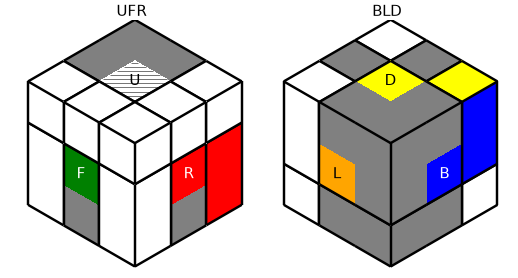

### Case 2

Execute `M1^-1: R2 F2 R F2 R F2 R' F' R F'`.

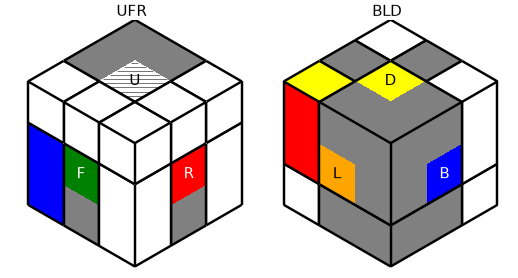

### Case 3

Execute `M3: F R' U F2 U' F R F2 R' F2 R`.

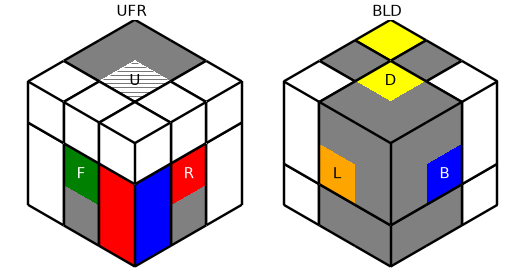

Also correct automatically after this stage: place Pair BR-DBR.

## Stage 2: Solve Pair FL-DFL

This stage has 2 exact cases and 1 instruction family. It reduces the remaining possibilities from 108 to 54.

### Case 1

Skip — already correct

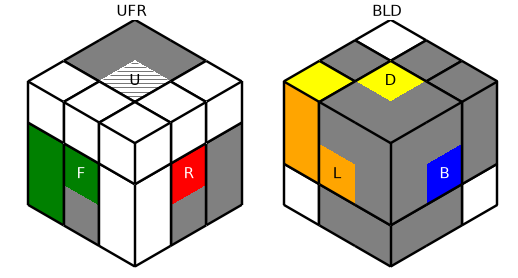

### Case 2

Execute `M4: F R2 F' R2 F R U' R2 U F' R`.

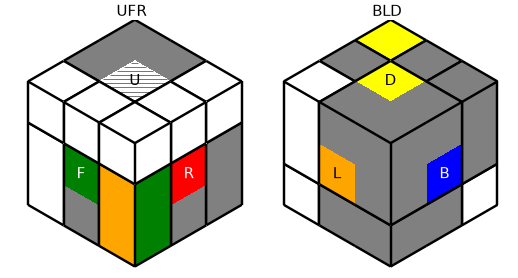

Also correct automatically after this stage: place Edge UR; place Edge UF; place Pair FL-DFL; place Pair FR-DFR; fully solve Pair FR-DFR.

## Stage 3: Orient Edge UR

This stage has 2 exact cases and 1 instruction family. It reduces the remaining possibilities from 54 to 27.

### Case 1

Skip — already correct

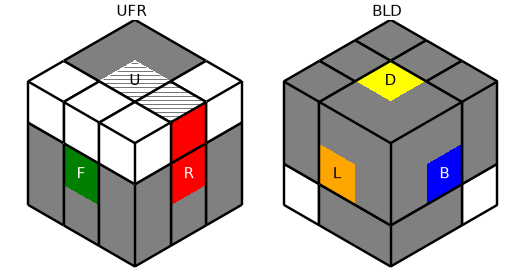

### Case 2

Execute `M2^-1: U' R U R2 F R F2 U F U'`.

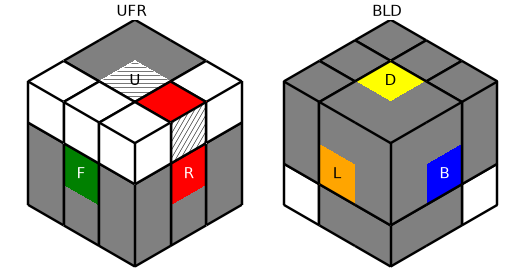

Also correct automatically after this stage: fully solve Edge UF.

## Stage 4: Solve Corner UBR

This stage has 9 exact cases and 6 instruction families. It reduces the remaining possibilities from 27 to 3.

### Case 1

Skip — already correct

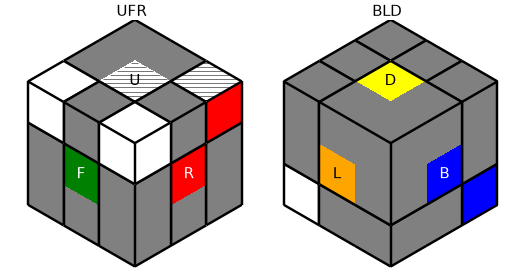

### Case 2

Execute `M2^2: U F' U' F2 R' F' R2 U' R' U2 F' U' F2 R' F' R2 U' R' U`.

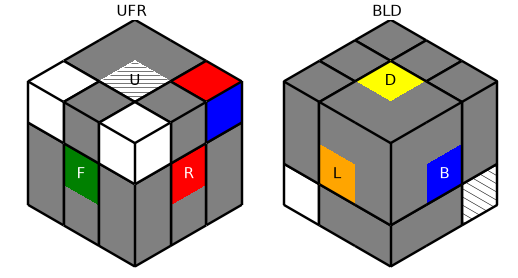

### Case 3

Execute `M2^-2: U' R U R2 F R F2 U F U2 R U R2 F R F2 U F U'`.

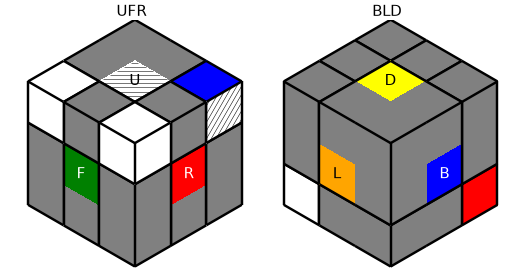

### Case 4

Execute `(M8^-1 M11)^-1: U F U' R' U' R U F' U' R' U R F U F' U' R' U F U' F' U' R U`.

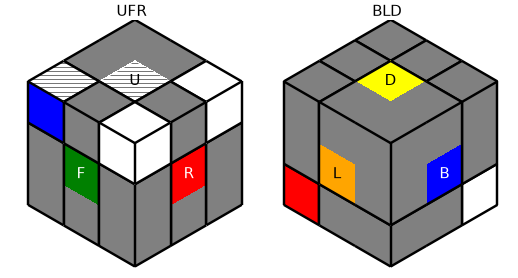

### Case 5

Execute `(M11 M8^-1)^-1: F U F' U' R' U F U' F' U' R U2 F U' R' U' R U F' U' R' U R`.

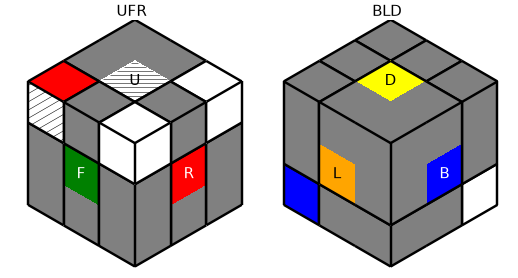

### Case 6

Execute `M8^-1: U' R' U F U F' U' R U F U' F'`.

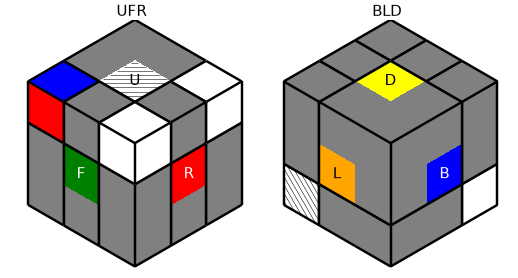

### Case 7

Execute `M8: F U F' U' R' U F U' F' U' R U`.

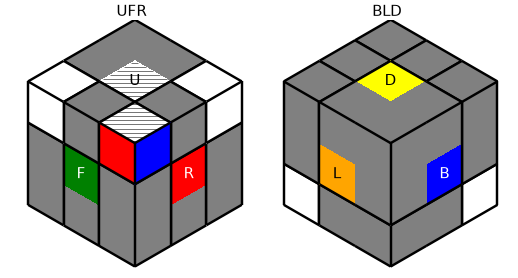

### Case 8

Execute `(M8^((M1^-1 M8)^-1))^-1: R2 F2 R F2 R F2 R' F' R F' U' R' U F U F' U' R U F U' R' F R F2 R' F2 R' F2 R2`.

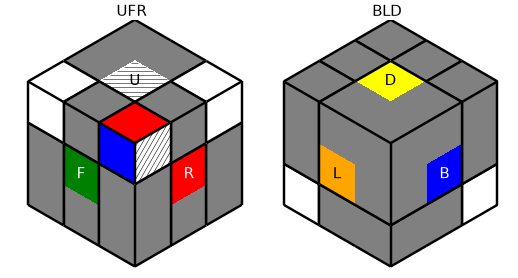

### Case 9

Execute `M11^-1: U F U' R' U' R U F' U' R' U R`.

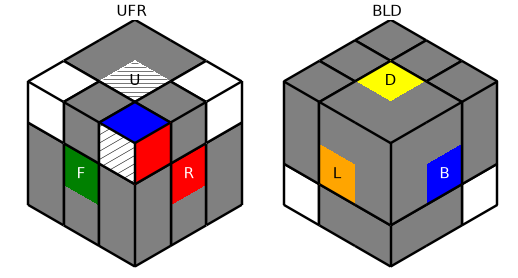

Also correct automatically after this stage: place Corner UBR; place Corner UFL; place Corner UFR.

## Stage 5: Orient Corner UFL

This stage has 3 exact cases and 1 instruction family. It reduces the remaining possibilities from 3 to 1.

### Case 1

Skip — already correct

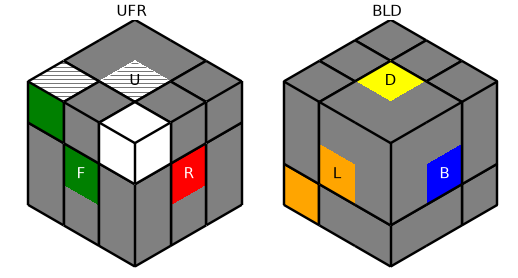

### Case 2

Execute `(M8 M11)^-1: U F U' R' U' R U F' U' R' U R U' R' U F U F' U' R U F U' F'`.

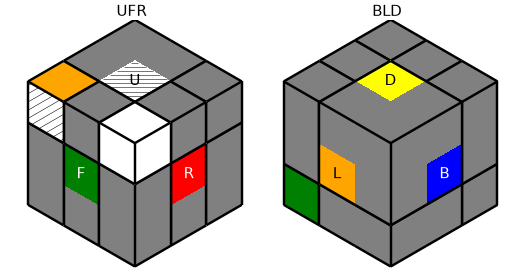

### Case 3

Execute `M8 M11: F U F' U' R' U F U' F' U' R U R' U' R U F U' R' U R U F' U'`.

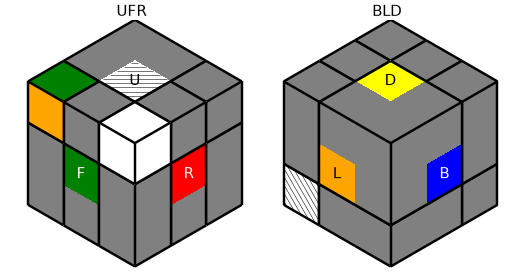

Also correct automatically after this stage: fully solve Corner UFR.

After the final stage every modeled corner and edge sticker is solved. Unmarked center spin and independent virtual-core spin are outside this model.


In [ ]:
repertoire = c.template_human_repertoire(analysis, preference=preference, backend="symbolic", progress=None)
display(Markdown(repertoire.write_guide(diagram_mode=diagram_mode, face_colors=face_colors)))


Optional shape graph. Configure and run the following cell when you want to draw the graph. `graph_view="auto"` draws small graphs and summarizes graphs above 1,000 shapes. Use `"local"` for a bounded neighborhood, or explicitly set `graph_view="full"` to draw every shape. Full layouts of large graphs can be expensive.


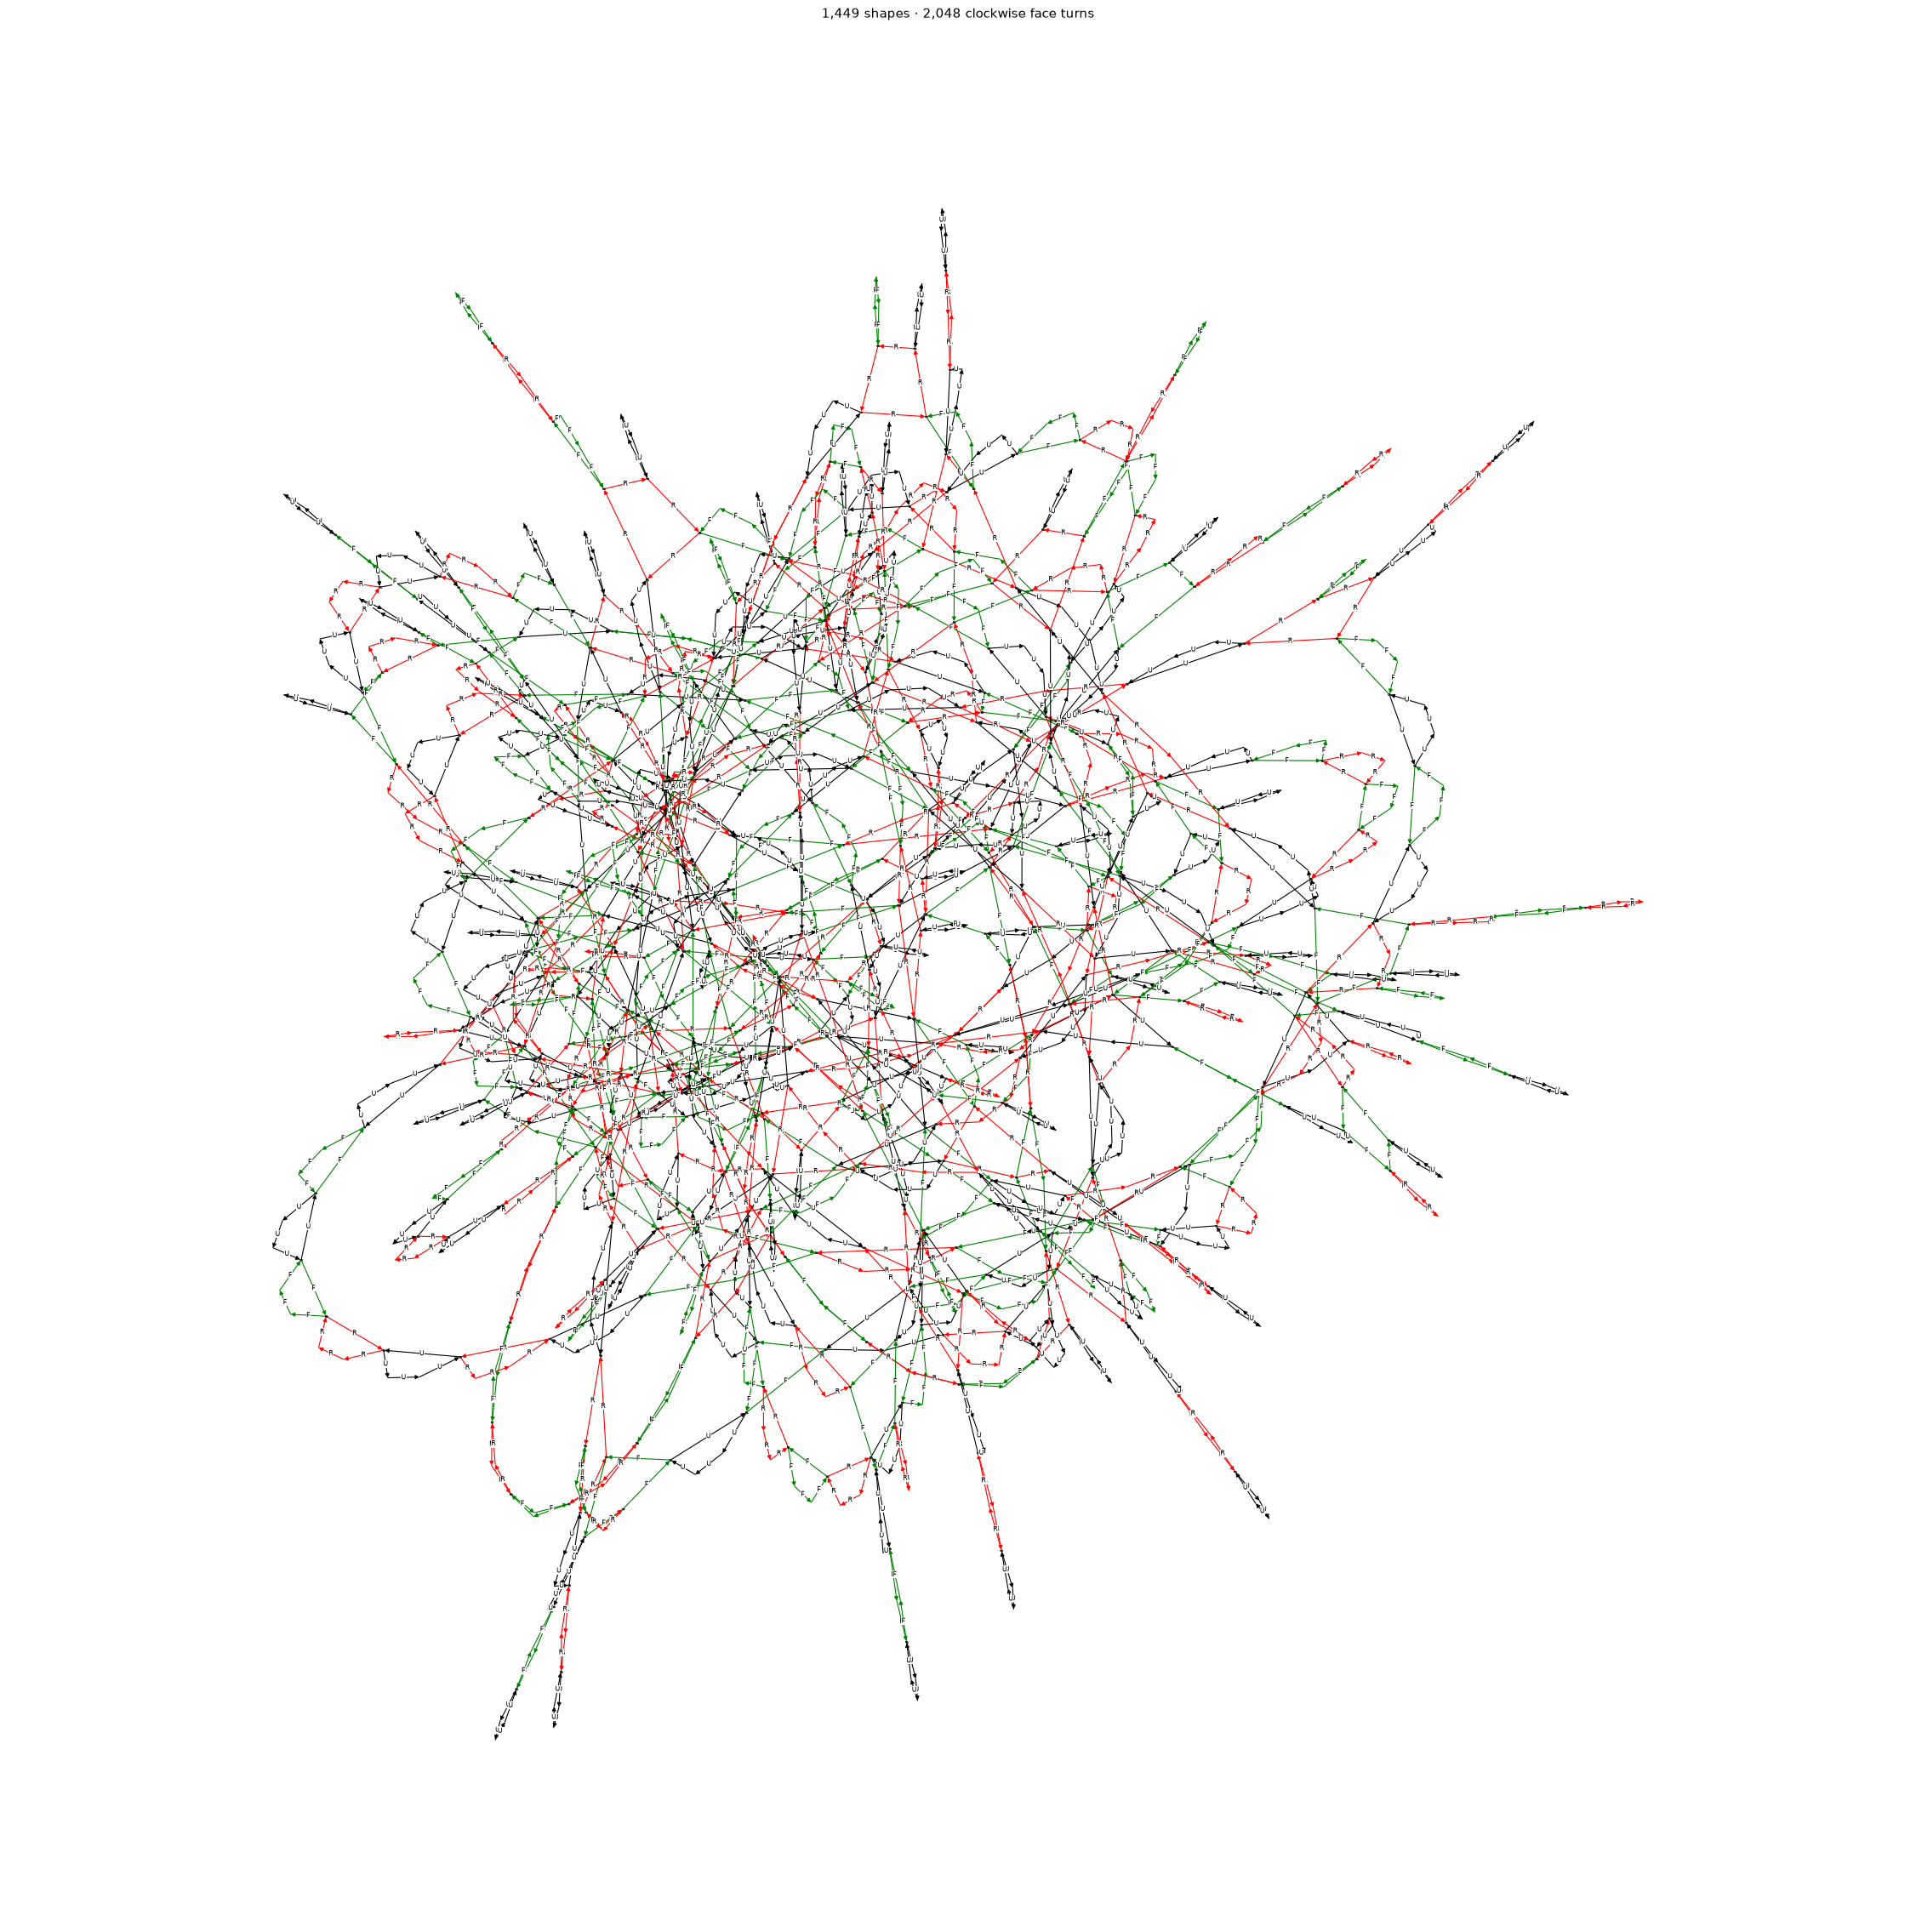

In [ ]:
import matplotlib.pyplot as plt

graph_view = "auto"  # "summary", "local", or explicit "full"
graph_max_vertices = 1000  # full auto drawings and local neighborhoods are bounded
graph_radius = 2  # used only for the local view
graph_layout = "symmetry"
graph_show_shapes = True
graph_edge_labels = True
graph_figsize = None  # automatic; override with (width, height) in inches
graph_shape_size = None  # automatic; override with a width in inches

shape_graph = c.explore(bandage)
graph_figure = c.draw_bandage_graph(
    shape_graph, view=graph_view, max_vertices=graph_max_vertices, radius=graph_radius,
    layout=graph_layout, show_shapes=graph_show_shapes,
    edge_labels=graph_edge_labels, face_colors=face_colors,
    diagram_mode=diagram_mode, figsize=graph_figsize, shape_size=graph_shape_size,
)
display(graph_figure)
plt.close(graph_figure)
